In [14]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

base = '/content/drive/MyDrive/AI_Project_Body_Fat_Percentage_Mesuring'
df = pd.read_csv(f'{base}/Processed/clean_bodyfat_dataset.csv')

print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(5628, 11)


,SEQN,RIDAGEYR,RIAGENDR,BMXWT,BMXHT,BMXBMI,BMXWAIST,BMXARMC,BMXCALF,BMXTHICR,DXDTOPF
0,31128.0,11.0,2.0,40.1,151.6,17.45,62.8,21.7,29.3,39.5,22.90
1,31129.0,15.0,1.0,74.6,167.7,26.53,97.8,32.6,40.6,55.9,30.00
2,31131.0,44.0,2.0,75.2,156.0,30.90,96.0,35.8,36.6,53.7,41.90
3,31133.0,16.0,2.0,45.0,163.7,16.79,62.0,22.3,31.7,41.3,17.46
4,31137.0,14.0,2.0,79.9,169.6,27.78,89.0,31.8,41.1,60.4,41.26


In [15]:
from sklearn.model_selection import train_test_split

feature_cols = ['RIDAGEYR', 'RIAGENDR', 'BMXWT', 'BMXHT', 'BMXBMI',
                 'BMXWAIST', 'BMXARMC', 'BMXCALF', 'BMXTHICR']

X = df[feature_cols]
y = df['DXDTOPF']
# First split: separate 15% for the final test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)

# Second split: from the remaining 85%, take 15% of the total for validation
# (0.15 / 0.85 ≈ 0.1765)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42)

print(len(X_train), len(X_val), len(X_test))

3938 845 845


In [16]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # learn from train only
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_s,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)

y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_t   = torch.tensor(y_val.values,   dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).view(-1, 1)

In [17]:
class BodyFatNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size,64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = BodyFatNet(input_size=X_train_t.shape[1])
print(model)

BodyFatNet(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [18]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [19]:
import copy
import torch.nn as nn

torch.manual_seed(42)
model = BodyFatNet(input_size=X_train_t.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_val_loss = float('inf')
best_epoch = 0

train_losses = []   # stores train loss for every epoch (used for the graph)
val_losses = []     # stores validation loss for every epoch

for epoch in range(5000):
    model.train()
    optimizer.zero_grad()
    loss = criterion(model(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), y_val_t).item()

    train_losses.append(loss.item())
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())

    # Print an update every 500 epochs
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:5d} | Train loss: {loss.item():.4f} | "
              f"Val loss: {val_loss:.4f} | Best so far: epoch {best_epoch}")

print("\nBest epoch:", best_epoch)

Epoch   500 | Train loss: 17.0672 | Val loss: 16.0243 | Best so far: epoch 499
Epoch  1000 | Train loss: 11.5373 | Val loss: 10.6732 | Best so far: epoch 999
Epoch  1500 | Train loss: 10.7711 | Val loss: 10.0652 | Best so far: epoch 1499
Epoch  2000 | Train loss: 10.4608 | Val loss: 9.8368 | Best so far: epoch 1999
Epoch  2500 | Train loss: 10.2683 | Val loss: 9.7449 | Best so far: epoch 2499
Epoch  3000 | Train loss: 10.1093 | Val loss: 9.6705 | Best so far: epoch 2998
Epoch  3500 | Train loss: 9.9589 | Val loss: 9.6699 | Best so far: epoch 3124
Epoch  4000 | Train loss: 9.8014 | Val loss: 9.7106 | Best so far: epoch 3124
Epoch  4500 | Train loss: 9.6387 | Val loss: 9.7854 | Best so far: epoch 3124
Epoch  5000 | Train loss: 9.4925 | Val loss: 9.8648 | Best so far: epoch 3124

Best epoch: 3124


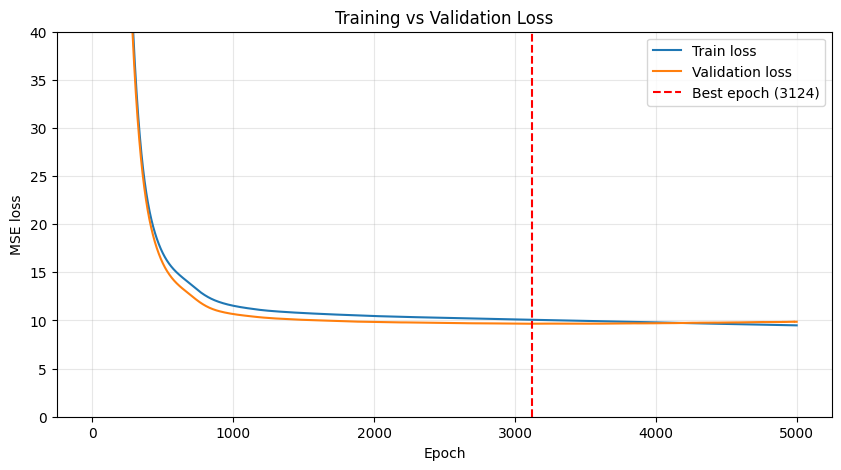

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.axvline(best_epoch, color="red", linestyle="--",
            label=f"Best epoch ({best_epoch})")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training vs Validation Loss")
plt.ylim(0, 40)     # cuts off the huge early losses so the useful part is visible
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("/content/drive/MyDrive/AI_Project_Body_Fat_Percentage_Mesuring/loss_curve.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model.load_state_dict(best_model_state)
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).numpy().flatten()

print("MAE: ", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:  ", r2_score(y_test, y_pred))

MAE:  2.5466395962506354
RMSE: 3.2268751471763837
R²:   0.8769657598700127


In [22]:
import joblib
import json

# Recalculate test predictions using the best weights
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).numpy().flatten()

models_dir = "/content/drive/MyDrive/AI_Project_Body_Fat_Percentage_Mesuring/Models/"

# 1. Make sure the model holds the BEST weights (not the last epoch's)
model.load_state_dict(best_model_state)
torch.save(model.state_dict(), models_dir + "bodyfat_nn_final.pt")

# 2. Save the scaler that was fit on THIS training set
joblib.dump(scaler, models_dir + "nn_scaler_final.joblib")

# 3. Save the details you'll need later to rebuild and use the model
info = {
    "architecture": "9 -> 64 -> 32 -> 1 (ReLU)",
    "features": list(X.columns),          # exact input order the model expects
    "split": "70/15/15 train/val/test, random_state=42",
    "seed": 42,
    "learning_rate": 0.001,
    "best_epoch": int(best_epoch),
    "test_MAE": float(mean_absolute_error(y_test, y_pred)),
    "test_RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
    "test_R2": float(r2_score(y_test, y_pred))
}
with open(models_dir + "nn_final_info.json", "w") as f:
    json.dump(info, f, indent=2)

print("Saved: bodyfat_nn_final.pt, nn_scaler_final.joblib, nn_final_info.json")
print(json.dumps(info, indent=2))

Saved: bodyfat_nn_final.pt, nn_scaler_final.joblib, nn_final_info.json
{
  "architecture": "9 -> 64 -> 32 -> 1 (ReLU)",
  "features": [
    "RIDAGEYR",
    "RIAGENDR",
    "BMXWT",
    "BMXHT",
    "BMXBMI",
    "BMXWAIST",
    "BMXARMC",
    "BMXCALF",
    "BMXTHICR"
  ],
  "split": "70/15/15 train/val/test, random_state=42",
  "seed": 42,
  "learning_rate": 0.001,
  "best_epoch": 3124,
  "test_MAE": 2.5466395962506354,
  "test_RMSE": 3.2268751471763837,
  "test_R2": 0.8769657598700127
}
